In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.3 MB/s eta 0:00:00


In [ ]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import numpy as np

Этапы:
* загрузка модели, предсказание
* убрать дублирование порожков
* фильтруем порожки по пересечению с рукой
* строим линии по отфильтрованным порожкам.
* строим струны
  * определить ось грифа
  * отсортировать порожки
  * выровнять порядок точек (то есть сделать так, чтобы все линии у порожков имели одинаковое напрваление)
  * взять точки одной и той же струны с каждого порожка и провести с их помощью линию
  * визуализация полученных линий (надо проверить, с каким форматом работаю в новой версии)

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/sample_data/yolo26m-obb.pt')
coord = model.predict("/content/sample_data/pics/guitar_capo1.jpg", save=True, conf=0.15)


image 1/1 /content/sample_data/pics/guitar_capo1.jpg: 768x1024 1 capo, 18 frets, 1 neck, 2 nuts, 3602.6ms
Speed: 12.2ms preprocess, 3602.6ms inference, 0.4ms postprocess per image at shape (1, 3, 768, 1024)
Results saved to /content/runs/obb/predict6


In [ ]:
res = coord[0]

print("Атрибуты:", [attr for attr in dir(res) if not attr.startswith('_')][:15])
print("Есть ли .obb?", hasattr(res, 'obb') and res.obb is not None)
print("Есть ли .boxes?", hasattr(res, 'boxes') and res.boxes is not None)
print("Классы:", res.names)
if hasattr(res, 'obb') and res.obb is not None:
    print("Количество OBB:", len(res.obb))
if hasattr(res, 'boxes') and res.boxes is not None:
    print("Количество обычных боксов:", len(res.boxes))

Атрибуты: ['boxes', 'cpu', 'cuda', 'keypoints', 'masks', 'names', 'new', 'numpy', 'obb', 'orig_img', 'orig_shape', 'path', 'plot', 'probs', 'save']
Есть ли .obb? True
Есть ли .boxes? False
Классы: {0: 'capo', 1: 'fret', 2: 'neck', 3: 'nut'}
Количество OBB: 22


In [ ]:
def get_obb_boxes(results):
    # results = model.predict(source=image_path, verbose=False)

    boxes = []

    obb = res.obb

    if obb is None:
        return boxes

    xyxyxyxy = obb.xyxyxyxy.cpu().numpy()
    classes = obb.cls.cpu().numpy().astype(int)

    for i in range(len(xyxyxyxy)):
        corners = xyxyxyxy[i]          # shape (4,2)
        class_id = classes[i]

        boxes.append((class_id, corners))

    return boxes


In [ ]:
def build_detections(boxes, model):
    detections = []

    for class_id, corners in boxes:
        class_name = model.names[class_id]

        detections.append({
            "class_id": class_id,
            "class": class_name,
            "xyxyxyxy": corners
        })

    return detections


In [ ]:
def remove_duplicate_frets(frets, iou_threshold=0.9):
    def iou(boxA, boxB):
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])

        inter = max(0, xB - xA) * max(0, yB - yA)

        areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
        areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])

        union = areaA + areaB - inter
        return inter / union if union > 0 else 0

    unique = []

    for f in frets:
        bboxA = polygon_to_bbox(f["xyxyxyxy"])
        duplicate = False

        for u in unique:
            bboxB = polygon_to_bbox(u["xyxyxyxy"])
            if iou(bboxA, bboxB) > iou_threshold:
                duplicate = True
                break

        if not duplicate:
            unique.append(f)

    return unique


Найдено рук: 2


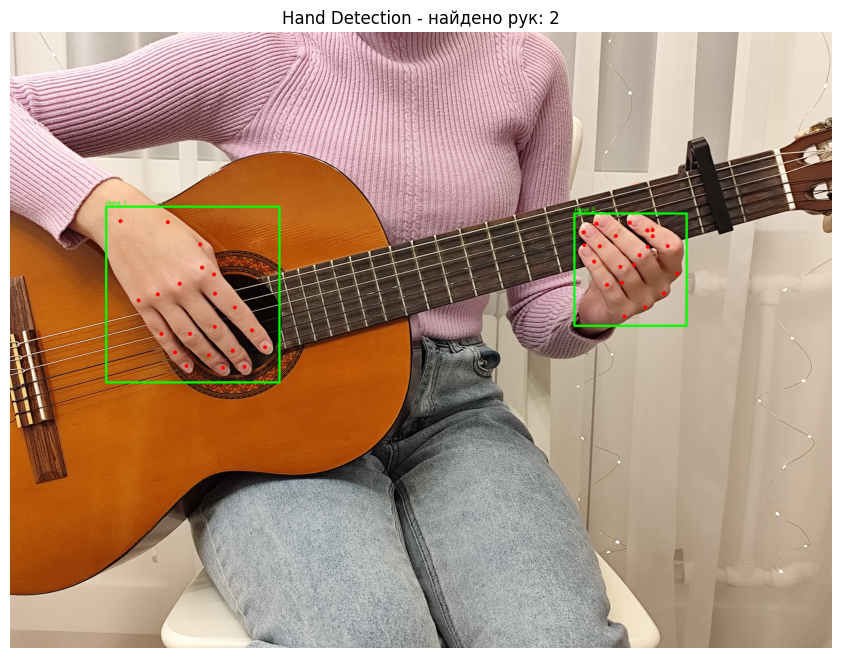


Bounding box'ы рук:
  Рука 1: (477, 867) - (1337, 1740) | ширина: 860, высота: 873
  Рука 2: (2801, 901) - (3358, 1459) | ширина: 557, высота: 558


In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 0. Скачиваем модель, если её нет ---
if not os.path.exists('hand_landmarker.task'):
    !wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

# --- 1. Создаём детектор HandLandmarker ---
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2
)
detector = vision.HandLandmarker.create_from_options(options)

# --- 2. Загружаем изображение ---
img_path = "/content/sample_data/pics/guitar_capo1.jpg"
image = mp.Image.create_from_file(img_path)

# --- 3. Детектируем руки ---
detection_result = detector.detect(image)

# --- 4. Получаем bounding box'ов рук ---
hand_boxes = []  # список [x1, y1, x2, y2]
hand_landmarks_list = []

# Получаем размер изображения
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

if detection_result.hand_landmarks:
    for hand_landmarks in detection_result.hand_landmarks:
        # Получаем координаты всех ключевых точек
        x_coords = [lm.x * w for lm in hand_landmarks]
        y_coords = [lm.y * h for lm in hand_landmarks]

        # bounding box без padding
        x1, y1 = int(min(x_coords)), int(min(y_coords))
        x2, y2 = int(max(x_coords)), int(max(y_coords))

        # Добавляем padding 10%
        pad_x = int(0.1 * (x2 - x1))
        pad_y = int(0.1 * (y2 - y1))
        x1 = max(0, x1 - pad_x)
        y1 = max(0, y1 - pad_y)
        x2 = min(w, x2 + pad_x)
        y2 = min(h, y2 + pad_y)

        hand_boxes.append([x1, y1, x2, y2])
        hand_landmarks_list.append(hand_landmarks)

    print(f"Найдено рук: {len(hand_boxes)}")
else:
    print("Руки не обнаружены")
    hand_boxes = []

# --- 5. Визуализация через OpenCV и Matplotlib ---

# Копия изображения для визуализации
img_visual = img_rgb.copy()

# Рисуем bounding box'ы
for i, (x1, y1, x2, y2) in enumerate(hand_boxes):
    # Рисуем прямоугольник
    cv2.rectangle(img_visual, (x1, y1), (x2, y2), (0, 255, 0), 10)

    # Добавляем подпись с номером руки
    cv2.putText(img_visual, f"Hand {i+1}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Рисуем ключевые точки (если есть)
if hand_landmarks_list:
    for hand_landmarks in hand_landmarks_list:
        for lm in hand_landmarks:
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(img_visual, (x, y), 10, (255, 0, 0), -1)

# --- 6. Отображаем через matplotlib ---
plt.figure(figsize=(12, 8))
plt.imshow(img_visual)
plt.title(f"Hand Detection - найдено рук: {len(hand_boxes)}")
plt.axis('off')
plt.show()

# --- 7. (Опционально) Отображаем через OpenCV в отдельном окне ---
# cv2.imshow("Hand Detection", cv2.cvtColor(img_visual, cv2.COLOR_RGB2BGR))
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# --- 8. Выводим информацию о bounding box'ах ---
print("\nBounding box'ы рук:")
for i, (x1, y1, x2, y2) in enumerate(hand_boxes):
    print(f"  Рука {i+1}: ({x1}, {y1}) - ({x2}, {y2}) | ширина: {x2-x1}, высота: {y2-y1}")

In [ ]:
import cv2
import matplotlib.pyplot as plt

def draw_obb(image, corners, color=(0,255,0), thickness=9):
    pts = np.array(corners, dtype=np.int32).reshape((-1,1,2))
    cv2.polylines(image, [pts], isClosed=True, color=color, thickness=thickness)



def visualize_detections(image, detections):
    vis_img = image.copy()

    for d in detections:
        corners = d["xyxyxyxy"]

        if d["class"] == "neck":
            color = (0,255,0)
        elif d["class"] == "nut":
            color = (255,0,0)
        elif d["class"] == "fret":
            color = (0,0,255)
        else:
            color = (255,255,0)

        draw_obb(vis_img, corners, color=color)

    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


In [ ]:
def polygon_to_bbox(corners):
    """
    corners: (4,2)
    returns: [x1, y1, x2, y2]
    """
    xs = corners[:, 0]
    ys = corners[:, 1]
    return [xs.min(), ys.min(), xs.max(), ys.max()]


def bboxes_intersect(boxA, boxB):
    """
    box: [x1, y1, x2, y2]
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    return (xA < xB) and (yA < yB)


neck: 1, nut: 2, fret: 18


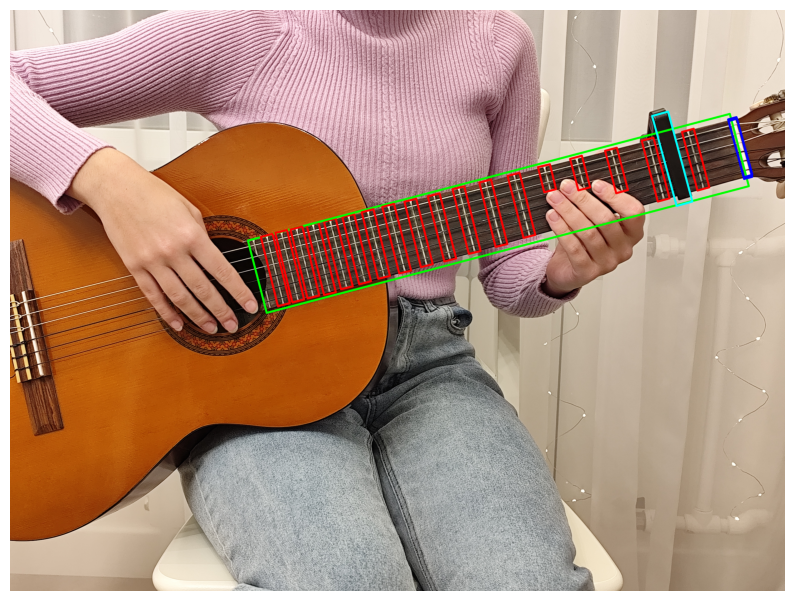

In [ ]:
image = cv2.imread(img_path)

boxes = get_obb_boxes(img_path)

detections = build_detections(boxes, model)

neck_boxes = [d for d in detections if d['class'] == 'neck']
nut_boxes  = [d for d in detections if d['class'] == 'nut']
fret_boxes = [d for d in detections if d['class'] == 'fret']
capo_boxes = [d for d in detections if d['class'] == 'capo']

fret_boxes = remove_duplicate_frets(fret_boxes, iou_threshold=0.8)


nut = nut_boxes[0]

print(f"neck: {len(neck_boxes)}, nut: {len(nut_boxes)}, fret: {len(fret_boxes)}")

# Визуализация
visualize_detections(image, detections)


In [ ]:
def fret_center_line(corners):
    """
    corners: (4,2) по часовой стрелке
    returns: (p1, p2) — две точки линии
    """

    # гарантируем numpy
    pts = np.array(corners)

    # стороны
    edges = [
        (pts[0], pts[1]),
        (pts[1], pts[2]),
        (pts[2], pts[3]),
        (pts[3], pts[0]),
    ]

    # длины сторон
    lengths = [np.linalg.norm(a - b) for a, b in edges]

    # индексы двух самых коротких сторон
    idx = np.argsort(lengths)[:2]

    # середины этих сторон
    midpoints = []
    for i in idx:
        a, b = edges[i]
        midpoint = (a + b) / 2
        midpoints.append(midpoint)
    # midpoints = [(edges[i][0] + edges[i][1]) / 2 for i in idx]

    return midpoints[0], midpoints[1]


In [ ]:
def compute_fret_geometry(fret, outer_gap_ratio=0.1): # 0.086
    corners = np.asarray(fret["xyxyxyxy"], dtype=np.float32)

    # 1. Получаем устойчивую центральную линию
    p1, p2 = fret_center_line(corners)

    # 2. Вектор вдоль порожка
    direction = p2 - p1
    length = np.linalg.norm(direction)

    if length < 1e-6:
        return fret  # защита от вырожденного случая

    direction /= length

    # 3. Геометрия струн
    outer_gap = outer_gap_ratio * length
    span = length - 2 * outer_gap

    offsets = np.linspace(-span / 2, span / 2, 6)
    center = (p1 + p2) / 2

    string_points = np.array([
        center + off * direction for off in offsets
    ], dtype=np.float32)

    fret["center_line"] = (p1, p2)
    fret["string_points"] = string_points

    return fret

In [ ]:
fltr_frets = []
rejected_frets = []

for fret in fret_boxes:
    corners = fret["xyxyxyxy"]
    fret_bbox = polygon_to_bbox(corners)

    intersects = False

    for hand_box in hand_boxes:
        if bboxes_intersect(fret_bbox, hand_box):
            intersects = True
            rejected_frets.append(fret)
            break

    if not intersects:
        fltr_frets.append(fret)

fltr_frets = [compute_fret_geometry(f) for f in fltr_frets]
rejected_frets = [compute_fret_geometry(f) for f in rejected_frets]

print(f"Всего порожков: {len(fret_boxes)}")
print(f"После фильтрации: {len(fltr_frets)}")


Всего порожков: 18
После фильтрации: 13


In [ ]:
filtered_detections = []

for d in detections:
    if d["class"] == "fret":
        continue
    filtered_detections.append(d)

filtered_detections.extend(fltr_frets)


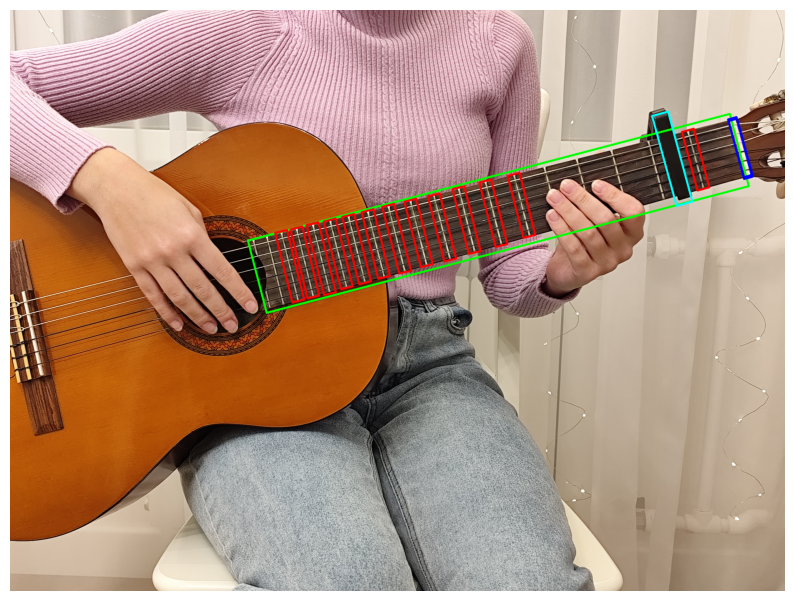

In [ ]:
visualize_detections(image, filtered_detections)


Строим линии по отфильтрованным порожкам

In [ ]:
def draw_line(image, p1, p2, color=(255,255,0), thickness=2):
    p1 = tuple(np.int32(p1))
    p2 = tuple(np.int32(p2))
    cv2.line(image, p1, p2, color, thickness)

In [ ]:
def visualize_fret_lines(image, frets):
    vis_img = image.copy()

    for fret in frets:
        corners = fret["xyxyxyxy"]

        # рисуем OBB
        #draw_obb(vis_img, corners, color=(0,0,255))

        # строим линию
        p1, p2 = fret_center_line(corners)

        # рисуем линию
        draw_line(vis_img, p1, p2, color=(0,255,0), thickness=3)

    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


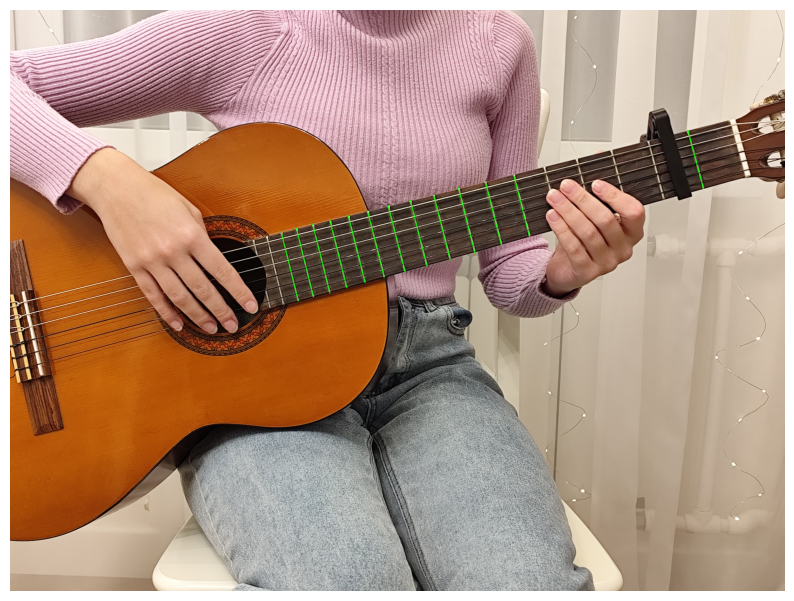

In [ ]:
visualize_fret_lines(image, fltr_frets)

## Построение струн

In [ ]:
import numpy as np

def fit_line_svd(points):
    """
    points: (N,2)
    return:
        centroid — точка на линии
        direction — нормированный вектор направления
    """

    pts = np.array(points)

    centroid = pts.mean(axis=0)
    centered = pts - centroid

    _, _, vh = np.linalg.svd(centered)

    direction = vh[0]
    direction = direction / np.linalg.norm(direction)

    return centroid, direction


In [ ]:
def line_to_image_bounds(point, direction, img_shape):
    """
    Возвращает две точки линии на границах изображения
    """

    h, w = img_shape[:2]

    dx, dy = direction
    x0, y0 = point

    points = []

    # пересечение с левым краем (x=0)
    if dx != 0:
        t = (0 - x0) / dx
        y = y0 + t * dy
        if 0 <= y <= h:
            points.append([0, y])

    # правый край (x=w)
    if dx != 0:
        t = (w - x0) / dx
        y = y0 + t * dy
        if 0 <= y <= h:
            points.append([w, y])

    # верх (y=0)
    if dy != 0:
        t = (0 - y0) / dy
        x = x0 + t * dx
        if 0 <= x <= w:
            points.append([x, 0])

    # низ (y=h)
    if dy != 0:
        t = (h - y0) / dy
        x = x0 + t * dx
        if 0 <= x <= w:
            points.append([x, h])

    if len(points) >= 2:
        return np.array(points[0]), np.array(points[1])
    else:
        return None, None


In [ ]:
def compute_neck_axis(frets):
    centers = []

    for f in frets:
        p1, p2 = f["center_line"]
        centers.append((p1 + p2) / 2)

    centers = np.array(centers)

    centroid = centers.mean(axis=0)
    centered = centers - centroid

    _, _, vh = np.linalg.svd(centered)

    axis = vh[0]
    axis = axis / np.linalg.norm(axis)

    return axis


In [ ]:
def sort_frets_along_axis(frets, axis):
    projections = []

    for f in frets:
        p1, p2 = f["center_line"]
        center = (p1 + p2) / 2
        projections.append(np.dot(center, axis))

    sorted_idx = np.argsort(projections)

    return [frets[i] for i in sorted_idx]


In [ ]:
def align_string_direction(frets):
    ref_dir = frets[0]["string_points"][-1] - frets[0]["string_points"][0]

    for f in frets:
        cur_dir = f["string_points"][-1] - f["string_points"][0]

        if np.dot(ref_dir, cur_dir) < 0:
            f["string_points"] = f["string_points"][::-1]

    return frets


In [ ]:
def build_string_lines(frets, image):

    # 1. определить ось грифа
    axis = compute_neck_axis(frets)

    # 2. отсортировать порожки
    frets = sort_frets_along_axis(frets, axis)

    # 3. выровнять порядок точек
    frets = align_string_direction(frets)

    strings = []

    for i in range(6):

        # точки одной струны со всех порожков
        pts = [f["string_points"][i] for f in frets]

        centroid, direction = fit_line_svd(pts)

        p1, p2 = line_to_image_bounds(centroid, direction, image.shape)

        strings.append((p1, p2))

    return strings

'''def build_string_lines(frets, image):
    strings = []

    for i in range(6):

        # собрать точки i-й струны со всех порожков
        pts = [f["string_points"][i] for f in frets]

        centroid, direction = fit_line_svd(pts)

        p1, p2 = line_to_image_bounds(centroid, direction, image.shape)

        strings.append((p1, p2))

    return strings
'''

'def build_string_lines(frets, image):\n    strings = []\n\n    for i in range(6):\n\n        # собрать точки i-й струны со всех порожков\n        pts = [f["string_points"][i] for f in frets]\n\n        centroid, direction = fit_line_svd(pts)\n\n        p1, p2 = line_to_image_bounds(centroid, direction, image.shape)\n\n        strings.append((p1, p2))\n\n    return strings\n'

In [ ]:
def draw_strings(image, strings):
    vis = image.copy()

    for p1, p2 in strings:
        if p1 is not None:
            cv2.line(
                vis,
                tuple(np.int32(p1)),
                tuple(np.int32(p2)),
                (0,0,255),
                7
            )

    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


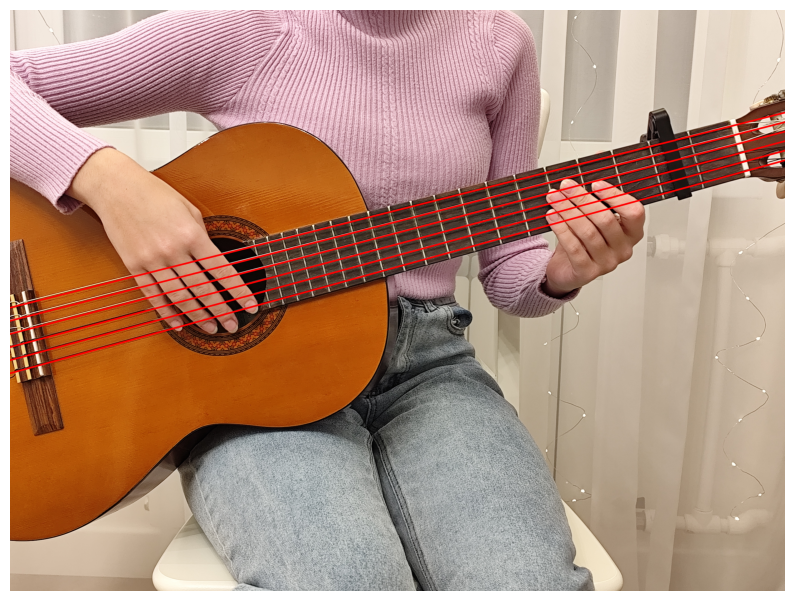

In [ ]:
strings = build_string_lines(fltr_frets, image)
draw_strings(image, strings)


# Построение сетки грифа

In [ ]:
nut_geom = compute_fret_geometry(nut)
nut_line_raw = nut_geom["center_line"]

x1, y1 = nut_line_raw[0]
x2, y2 = nut_line_raw[1]

nut_line = (float(x1), float(y1), float(x2), float(y2))

Работа с неотфильтрованными порожками

In [ ]:
def normalize(v):
    return v / np.linalg.norm(v)

def line_from_point_dir(point, direction):
    return np.array(point, dtype=float), normalize(direction)

def intersect_abc(l1, l2):
    a1, b1, c1 = l1
    a2, b2, c2 = l2

    det = a1 * b2 - a2 * b1
    if abs(det) < 1e-8:
        return None  # параллельны

    x = (b1 * c2 - b2 * c1) / det
    y = (c1 * a2 - c2 * a1) / det
    return np.array([x, y])


In [ ]:
'''
def intersect_lines(p1, d1, p2, d2):
    A = np.column_stack((d1, -d2))
    b = p2 - p1
    t, s = np.linalg.lstsq(A, b, rcond=None)[0]
    return p1 + t * d1
'''

In [ ]:
# получаем направление одного из отфильтрованных порожков
ref_p1, ref_p2 = fltr_frets[0]['center_line']
ref_dir = normalize(np.array(ref_p2) - np.array(ref_p1))

In [ ]:
vertical_lines = []

for fret in fltr_frets:
    p1, p2 = fret["center_line"]
    p, d = line_from_point_dir(p1, np.array(p2) - np.array(p1))
    vertical_lines.append((p, d))

In [ ]:
for fret in rejected_frets:
    corners = fret["xyxyxyxy"]
    center = np.mean(corners, axis=0)
    p, d = line_from_point_dir(center, ref_dir)
    vertical_lines.append((p, d))

In [ ]:
ref_dir = vertical_lines[0][1]

aligned_vertical_lines = []

for p, d in vertical_lines:
    if np.dot(d, ref_dir) < 0:
        d = -d
    aligned_vertical_lines.append((p, d))

vertical_lines = aligned_vertical_lines
# Сортируем по проекции точки на перпендикуляр к ref_dir
normal = np.array([-ref_dir[1], ref_dir[0]])

vertical_lines.sort(key=lambda line: np.dot(line[0], normal))

In [ ]:
# усреднение направлений
dirs = np.array([d for _, d in vertical_lines])
mean_dir = np.mean(dirs, axis=0)
mean_dir = mean_dir / np.linalg.norm(mean_dir)

# делаем все направления одинаковыми
vertical_lines = [(p, mean_dir) for p, _ in vertical_lines]

In [ ]:
def line_pd_to_abc(p, d):
    x0, y0 = p
    dx, dy = d

    # нормаль к направлению
    a = -dy
    b = dx
    c = -(a*x0 + b*y0)

    norm = np.sqrt(a*a + b*b)
    return a/norm, b/norm, c/norm

In [ ]:
frets_lines = []

for p, d in vertical_lines:
    abc = line_pd_to_abc(p, d)
    frets_lines.append(abc)

In [ ]:
h, w = image.shape[:2] # сортировка
mid_y = h // 2

fret_with_pos = []

test_line = (0, 1, -mid_y)  # y = mid_y

for line in frets_lines:
    p = intersect_abc(line, test_line)
    if p is not None:
        fret_with_pos.append((p[0], line))

fret_with_pos.sort(key=lambda x: x[0])
frets_lines = [x[1] for x in fret_with_pos]

In [ ]:
def segment_to_abc(line):
    x1, y1, x2, y2 = line
    a = y2 - y1
    b = x1 - x2
    c = x2*y1 - x1*y2
    norm = np.sqrt(a*a + b*b)
    if norm == 0:
        return None
    return a/norm, b/norm, c/norm


def intersect_lines(l1, l2):
    a1, b1, c1 = l1
    a2, b2, c2 = l2
    det = a1*b2 - a2*b1
    if abs(det) < 1e-9:
        return None
    x = (b1*c2 - b2*c1) / det
    y = (c1*a2 - c2*a1) / det
    return np.array([x, y])


In [ ]:
top_points = []
bottom_points = []

for item in fltr_frets:
    p1, p2 = item['center_line']  # сразу распаковываем

    y1 = p1[1]
    y2 = p2[1]

    if y1 < y2:
        top_points.append(p1)
        bottom_points.append(p2)
    else:
        top_points.append(p2)
        bottom_points.append(p1)

top_points = np.array(top_points, dtype=np.float32)
bottom_points = np.array(bottom_points, dtype=np.float32)

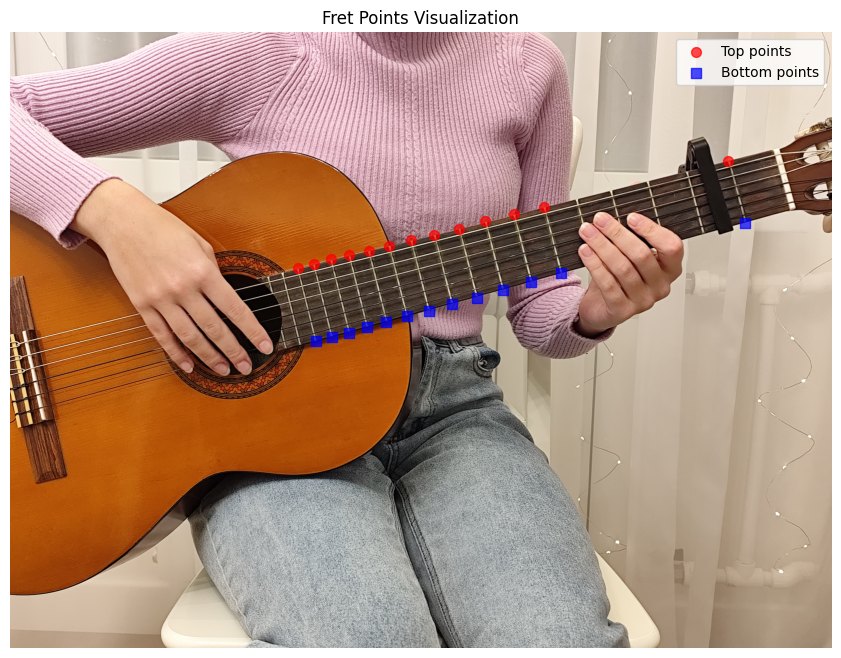

In [ ]:
# Создаем фигуру
plt.figure(figsize=(12, 8))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

# Визуализируем точки
plt.scatter(top_points[:, 0], top_points[:, 1],
           c='red', marker='o', s=50, label='Top points', alpha=0.7)
plt.scatter(bottom_points[:, 0], bottom_points[:, 1],
           c='blue', marker='s', s=50, label='Bottom points', alpha=0.7)

plt.legend()
plt.title('Fret Points Visualization')
plt.axis('off')  # отключаем оси
plt.show()

In [ ]:
def fit_line_through_points(points):
    x = points[:, 0]
    y = points[:, 1]
    A = np.vstack([x, np.ones_like(x)]).T
    k, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return k, b

top_k, top_b = fit_line_through_points(top_points)
bot_k, bot_b = fit_line_through_points(bottom_points)


In [ ]:
def kb_to_abc(k, b):
    # y = kx + b → kx - y + b = 0
    a = k
    b_coef = -1
    c = b
    norm = np.sqrt(a*a + b_coef*b_coef)
    return a/norm, b_coef/norm, c/norm

top_line = kb_to_abc(top_k, top_b)
bottom_line = kb_to_abc(bot_k, bot_b)


In [ ]:
nut_abc = segment_to_abc(nut_line)

fret_abc = [nut_abc] + frets_lines # [segment_to_abc(l) for l in frets_lines]

In [ ]:
fret_with_pos = []

test_line = (0, 1, -h//2)  # горизонтальная через центр

for line in fret_abc:
    p = intersect_lines(line, test_line)
    if p is not None:
        fret_with_pos.append((p[0], line))

fret_with_pos.sort(key=lambda x: x[0], reverse=True)
fret_abc = [x[1] for x in fret_with_pos]

In [ ]:
strings_lines = []

for s in strings:
    # s = (array([x1,y1]), array([x2,y2]))
    x1, y1 = s[0]
    x2, y2 = s[1]

    strings_lines.append(
        (float(x1), float(y1), float(x2), float(y2))
    )

string_with_pos = []

for line in strings_lines:
    abc = segment_to_abc(line)
    if abc is None:
        continue

    # пересечение с вертикальной линией x = w//2
    # x = const → 1*x + 0*y - w//2 = 0
    test_line = (1, 0, -w//2)
    p = intersect_lines(abc, test_line)
    if p is not None:
        string_with_pos.append((p[1], line))

string_with_pos.sort(key=lambda x: x[0], reverse=True)
strings_lines = [x[1] for x in string_with_pos]


In [ ]:
strings_abc = [segment_to_abc(l) for l in strings_lines]

In [ ]:
middle_lines = []

for i in range(len(strings_abc) - 1):
    a1, b1, c1 = strings_abc[i]
    a2, b2, c2 = strings_abc[i+1]

    a = (a1 + a2) / 2
    b = (b1 + b2) / 2
    c = (c1 + c2) / 2

    norm = np.sqrt(a*a + b*b)
    middle_lines.append((a/norm, b/norm, c/norm))


In [ ]:
horizontal_lines = [bottom_line] + middle_lines + [top_line]

In [ ]:
grid = []

for i in range(len(horizontal_lines) - 1):
    for j in range(len(fret_abc) - 1):

        p1 = intersect_lines(horizontal_lines[i],     fret_abc[j])
        p2 = intersect_lines(horizontal_lines[i],     fret_abc[j+1])
        p3 = intersect_lines(horizontal_lines[i+1],   fret_abc[j+1])
        p4 = intersect_lines(horizontal_lines[i+1],   fret_abc[j])

        if p1 is None or p2 is None or p3 is None or p4 is None:
            continue

        polygon = np.array([p1, p2, p3, p4], dtype=np.float32)

        grid.append({
            "string_zone": i,
            "fret_zone": j,
            "polygon": polygon
        })


In [ ]:
grid = []  # запускать эту ячейку

# Количество промежутков между линиями
num_horizontal_gaps = len(horizontal_lines) - 1
num_fret_gaps = len(fret_abc) - 1

for i in range(num_horizontal_gaps):  # i от 0 до num_horizontal_gaps-1
    for j in range(num_fret_gaps):    # j от 0 до num_fret_gaps-1

        # Используем линии с индексами i и i+1, j и j+1
        p1 = intersect_lines(horizontal_lines[i], fret_abc[j])
        p2 = intersect_lines(horizontal_lines[i], fret_abc[j+1])
        p3 = intersect_lines(horizontal_lines[i+1], fret_abc[j+1])
        p4 = intersect_lines(horizontal_lines[i+1], fret_abc[j])

        if p1 is None or p2 is None or p3 is None or p4 is None:
            continue

        polygon = np.array([p1, p2, p3, p4], dtype=np.float32)

        grid.append({
            "string_zone": i,      # индекс промежутка между струнами
            "fret_zone": j,        # индекс промежутка между ладами
            "polygon": polygon
        })

print(f"Создано ячеек: {len(grid)}")
print(f"Ожидалось: {num_horizontal_gaps * num_fret_gaps}")

Создано ячеек: 108
Ожидалось: 108


In [ ]:
frame_with_grid = image.copy() # запускать эту ячейку

# Рисуем все ячейки из grid
for cell in grid:
    polygon = cell["polygon"].astype(np.int32)
    row = cell["string_zone"]
    col = cell["fret_zone"]

    # шахматная раскраска
    if (row + col) % 2 == 0:
        color = (0, 255, 0)       # зелёный
    else:
        color = (255, 0, 255)     # пурпурный

    cv2.polylines(
        frame_with_grid,
        [polygon],
        isClosed=True,
        color=color,
        thickness=5
    )

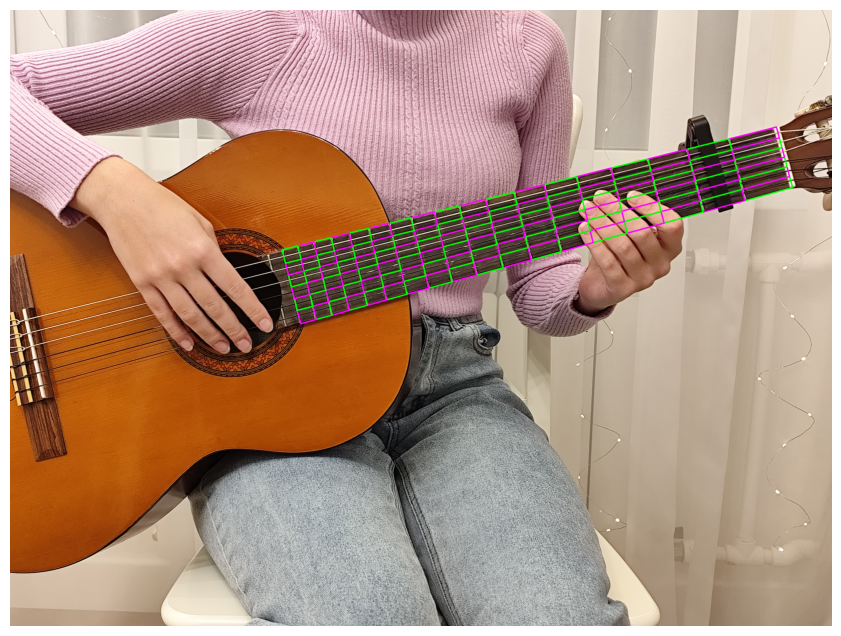

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(frame_with_grid, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


# Сопоставление сетки грифа и кончиков пальцев левой руки

In [ ]:
# Берём только кончики 4 пальцев (без большого)
fingertip_ids = [8, 12, 16, 20]

finger_positions = []

for hand_id, (hand_landmarks, handedness) in enumerate(
        zip(hand_landmarks_list, detection_result.handedness)):

    # Оставляем только левую руку (играющую на грифе)
    hand_label = handedness[0].category_name
    if hand_label != "Left":
        continue

    for tip_id in fingertip_ids:
        lm = hand_landmarks[tip_id]

        x = int(lm.x * w)
        y = int(lm.y * h)
        point = (x, y)

        for cell in grid:
            polygon = cell["polygon"].astype(np.int32)

            inside = cv2.pointPolygonTest(polygon, point, False)

            if inside >= 0:
                # Переводим индексы в музыкальные номера
                string_number = cell["string_zone"] + 1
                fret_number = cell["fret_zone"] + 1

                finger_positions.append({
                    "finger_id": tip_id,
                    "string": string_number,
                    "fret": fret_number,
                    "point": point
                })
                break

In [ ]:
finger_positions

[{'finger_id': 8, 'string': 3, 'fret': 4, 'point': (3075, 947)},
 {'finger_id': 12, 'string': 4, 'fret': 5, 'point': (2911, 952)},
 {'finger_id': 16, 'string': 3, 'fret': 6, 'point': (2847, 995)},
 {'finger_id': 20, 'string': 2, 'fret': 6, 'point': (2850, 1058)}]

In [ ]:
strings_state = [None] * 6

for fp in finger_positions:
    string_idx = fp["string"] - 1
    fret = fp["fret"]

    if strings_state[string_idx] is None:
        strings_state[string_idx] = fret
    else:
        strings_state[string_idx] = min(strings_state[string_idx], fret)

In [ ]:
print("Относительно nut:", strings_state)

Относительно nut: [None, 6, 4, 5, None, None]


Учет каподастра

In [ ]:
def get_center_from_obb(corners):
    pts = np.array(corners, dtype=np.float32).reshape(4, 2)
    cx = int(np.mean(pts[:, 0]))
    cy = int(np.mean(pts[:, 1]))
    return (cx, cy)


def detect_capo_fret(capo_boxes, grid):
    if len(capo_boxes) == 0:
        return None

    corners = capo_boxes[0]['xyxyxyxy']
    point = get_center_from_obb(corners)

    for cell in grid:
        polygon = cell["polygon"].astype(np.int32)
        inside = cv2.pointPolygonTest(polygon, point, False)

        if inside >= 0:
            return cell["fret_zone"] + 1

    return None

In [ ]:
def apply_capo(strings_state, capo_fret):
    if capo_fret is None:
        return strings_state.copy()

    adjusted = []

    for fret in strings_state:
        if fret is None:
            adjusted.append('-')
        elif fret >= capo_fret:
            adjusted.append(fret - capo_fret)
        else:
            adjusted.append(0)

    return adjusted

In [ ]:
capo_fret = detect_capo_fret(capo_boxes, grid)

if capo_fret is not None:
    print(f"Каподастр на ладу: {capo_fret}")
else:
    print("Каподастр не обнаружен")

Каподастр на ладу: 2


In [ ]:
strings_state = apply_capo(strings_state, capo_fret)

print("Относительно капо:", strings_state)

Относительно капо: ['-', 4, 2, 3, '-', '-']


Построение табов

In [ ]:
def print_tab(strings_state):
    open_notes = ["E", "B", "G", "D", "A", "E"]

    if capo_fret is not None:
        print(f"Capo fret {capo_fret}")

    print("\nТабулатура:")
    for i in range(6):
        print(f"{open_notes[i]}  --{strings_state[i]}--")

In [ ]:
print_tab(strings_state)

Capo fret 2

Табулатура:
E  -----
B  --4--
G  --2--
D  --3--
A  -----
E  -----
